In [1]:
from pathlib import Path
import sys
import json

import torch
from torchvision import transforms

# Nếu chưa có ROOT_DIR thì chắc chắn lại:
# - Notebook trong Jupyter/ → ROOT_DIR = Path.cwd()
# - Notebook trong Jupyter/evaluate/ → ROOT_DIR = parent
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "evaluate":
    ROOT_DIR = NOTEBOOK_DIR.parent
else:
    ROOT_DIR = NOTEBOOK_DIR

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("ROOT_DIR    :", ROOT_DIR)

# Thêm models vào sys.path
sys.path.append(str(ROOT_DIR / "models"))

from efficientnet_b0 import (
    build_model,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ====== CHỌN CHECKPOINT CẦN DÙNG ======
# 👉 chỉnh đúng run & tên file ở đây
RUN_NAME = "MTL_TGFOOD"          # ví dụ: run incremental 34 lớp
CKPT_FILE = "mtl_effcientnet_b0_best.pt"                  # hoặc "mtl_effb0_best.pt" với model 33 lớp

CKPT_PATH = ROOT_DIR / "runs" / RUN_NAME / "checkpoints" / CKPT_FILE
RUN_DIR   = CKPT_PATH.parent.parent

print("Classifier ckpt:", CKPT_PATH)
print("Run dir        :", RUN_DIR)

if not CKPT_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy checkpoint: {CKPT_PATH}")

# ====== LOAD CHECKPOINT ======
ckpt = torch.load(CKPT_PATH, map_location=device)

# 1) ưu tiên class_names trong checkpoint
class_names = ckpt.get("class_names", None)

# 2) nếu không có thì thử đọc classes.txt trong run
if class_names is None:
    classes_txt = RUN_DIR / "classes.txt"
    if classes_txt.exists():
        print("📄 Đọc class_names từ:", classes_txt)
        lines = classes_txt.read_text(encoding="utf-8").splitlines()
        class_names = [ln.strip() for ln in lines if ln.strip()]

# 3) nếu vẫn chưa có thì fallback sang runs_meta/class_names.json (global)
if class_names is None:
    runs_meta = ROOT_DIR.parent / "runs_meta" / "class_names.json"
    print("⚠️ Không tìm thấy class_names trong ckpt/run → fallback:", runs_meta)
    with open(runs_meta, "r", encoding="utf-8") as f:
        class_names = json.load(f)

num_classes = len(class_names)
print("Số class:", num_classes)
print("Một vài class đầu:", class_names[:10])

# ====== BUILD MODEL ĐÚNG SỐ LỚP & LOAD WEIGHTS ======
model = build_model(
    num_classes=num_classes,
    dropout=0.4,
    pretrained=False,      # dùng weight từ ckpt nên không cần ImageNet
    freeze_backbone=False, # chỉ để build, inference không ảnh hưởng
    device=device,
)

# Nếu checkpoint lưu kiểu {'model_state': ..., ...}
state = ckpt.get("model_state", ckpt)
model.load_state_dict(state)
model.eval()

print("✅ Loaded classifier model.")

# ====== TRANSFORM EVAL (KHÔNG AUGMENT) ======
to_rgb = transforms.Lambda(lambda im: im.convert("RGB"))
eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    to_rgb,
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


NOTEBOOK_DIR: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/evaluate
ROOT_DIR    : /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter
Device: cuda
Classifier ckpt: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/MTL_TGFOOD/checkpoints/mtl_effcientnet_b0_best.pt
Run dir        : /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/MTL_TGFOOD
Số class: 33
Một vài class đầu: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi']
✅ torch.compile enabled
✅ Loaded classifier model.


In [2]:
# Cell 3: Load YOLO detector (chỉ để tìm vùng có món ăn)

from ultralytics import YOLO

# 👉 chỉnh lại nếu ông muốn dùng yolov8n.pt / yolov8s-seg.pt
YOLO_WEIGHTS = ROOT_DIR / "yolo11n.pt"
print("YOLO weights:", YOLO_WEIGHTS)

yolo_model = YOLO(str(YOLO_WEIGHTS))
print("✅ Loaded YOLO model.")


YOLO weights: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/yolo11n.pt
✅ Loaded YOLO model.


In [3]:
# Cell 4: Hàm detect vùng món ăn bằng YOLO

from PIL import Image

def detect_food_boxes(image_path, conf_thres=0.4, allowed_yolo_classes=None):
    """
    Dùng YOLO để detect vật thể trên ảnh.
    Trả về:
      - img (PIL Image)
      - boxes: list tuple (x1, y1, x2, y2, yolo_label, score)
    """
    img = Image.open(image_path).convert("RGB")

    results = yolo_model.predict(
        source=str(image_path),
        conf=conf_thres,
        verbose=False,
    )

    boxes = []
    for r in results:
        if r.boxes is None:
            continue
        for b in r.boxes:
            x1, y1, x2, y2 = b.xyxy[0].cpu().numpy().tolist()
            cls_idx = int(b.cls.item())
            cls_name = r.names[cls_idx]
            score = float(b.conf.item())

            # Nếu muốn chỉ lấy vài class YOLO (vd 'bowl', 'cup'...), cấu hình ở allowed_yolo_classes
            if allowed_yolo_classes is not None:
                if cls_name not in allowed_yolo_classes:
                    continue

            boxes.append((x1, y1, x2, y2, cls_name, score))

    print(f"YOLO phát hiện {len(boxes)} vùng (conf ≥ {conf_thres}).")
    return img, boxes


In [4]:
# Cell 5: Crop từng bbox rồi ném vào classifier để nhận diện món ăn

from collections import defaultdict
import numpy as np

def expand_box(x1, y1, x2, y2, img_w, img_h, scale=1.2):
    """
    Nới rộng box quanh tâm theo tỉ lệ scale.
    scale=1.2 nghĩa là rộng/cao hơn 20%.
    """
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    w = (x2 - x1) * scale
    h = (y2 - y1) * scale

    nx1 = max(int(cx - w / 2), 0)
    ny1 = max(int(cy - h / 2), 0)
    nx2 = min(int(cx + w / 2), img_w)
    ny2 = min(int(cy + h / 2), img_h)

    return nx1, ny1, nx2, ny2


def crop_and_classify(img, boxes, prob_thres=0.5, expand_scale=1.2):
    """
    - boxes: (x1, y1, x2, y2, yolo_label, score) từ YOLO
    - expand_scale: hệ số nới rộng box (1.0 = giữ nguyên, 1.2 = rộng hơn 20%)
    """
    results = []
    counts = defaultdict(int)

    W, H = img.size

    for (x1, y1, x2, y2, yolo_label, det_score) in boxes:
        # nới rộng box quanh tâm
        x1p, y1p, x2p, y2p = expand_box(x1, y1, x2, y2, W, H, scale=expand_scale)

        crop = img.crop((x1p, y1p, x2p, y2p))

        timg = eval_tfms(crop).unsqueeze(0).to(device)

        with torch.no_grad(), torch.amp.autocast(device_type=device.type):
            logits = model(timg)
            probs = torch.softmax(logits, dim=1)
            pred_idx = int(torch.argmax(probs, dim=1).item())
            prob = float(probs[0, pred_idx].item())

        if prob < prob_thres:
            # classifier tự thấy không chắc thì bỏ
            continue

        dish_name = class_names[pred_idx]
        counts[dish_name] += 1

        results.append({
            "bbox": (x1p, y1p, x2p, y2p),   # lưu bbox đã nới rộng
            "dish_name": dish_name,
            "prob": prob,
            "yolo_label": yolo_label,
            "det_conf": det_score,
        })

    print(f"Sau khi lọc classifier (prob ≥ {prob_thres}): còn {len(results)} vùng.")
    return results, counts



In [5]:
from PIL import ImageDraw, ImageFont
import matplotlib.pyplot as plt

def visualize_results(img, results, font_size=16, save_path=None):
    drawn = img.copy()
    draw = ImageDraw.Draw(drawn)

    # font: cố gắng dùng font hệ thống, nếu fail thì dùng default
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except Exception:
        font = ImageFont.load_default()

    for r in results:
        x1, y1, x2, y2 = r["bbox"]
        dish = r["dish_name"]
        prob = r["prob"]

        label = f"{dish} ({prob:.2f})"
        draw.rectangle((x1, y1, x2, y2), outline="red", width=2)

        # ===== đo kích thước chữ cho Pillow mới =====
        if hasattr(draw, "textbbox"):
            bbox = draw.textbbox((0, 0), label, font=font)
            tw = bbox[2] - bbox[0]
            th = bbox[3] - bbox[1]
        else:
            tw, th = draw.textsize(label, font=font)
        # ============================================

        # nền đen cho label
        draw.rectangle((x1, y1 - th - 4, x1 + tw + 4, y1), fill="black")
        draw.text((x1 + 2, y1 - th - 2), label, fill="yellow", font=font)

    # nếu có đường dẫn lưu thì save ra file
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        drawn.save(save_path)
        print(f"💾 Đã lưu ảnh có box tại: {save_path}")

    # vẫn show trong notebook
    plt.figure(figsize=(8, 8))
    plt.imshow(drawn)
    plt.axis("off")
    plt.show()


Test image: /home/mtl/Downloads/6.jpg
YOLO phát hiện 15 vùng (conf ≥ 0.4).
Sau khi lọc classifier (prob ≥ 0.8): còn 8 vùng.
💾 Đã lưu ảnh có box tại: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/images/detect_foods/6_det.jpg


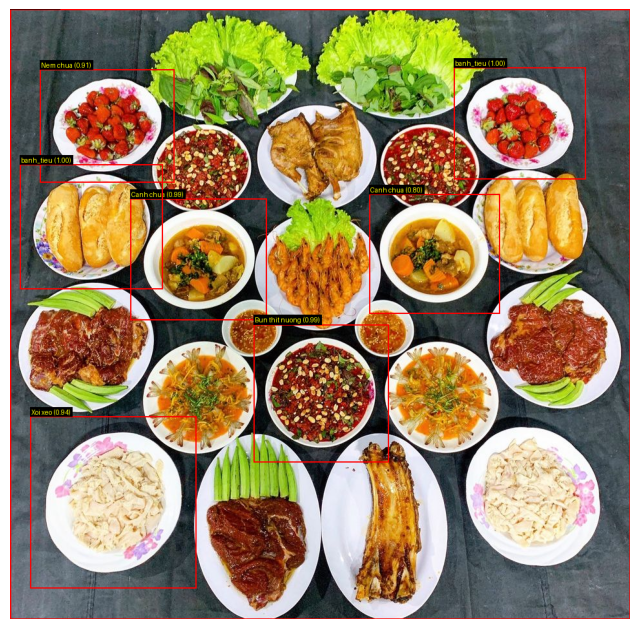

NameError: name 'print_summary_counts' is not defined

In [6]:
from pathlib import Path

# test_image = "/home/mtl/Downloads/banhcanh-3.jpg"  # ❌ string
test_image = Path("/home/mtl/Downloads/6.jpg")  # ✅ Path

print("Test image:", test_image)

# B1: detect vùng món ăn
img, boxes = detect_food_boxes(
    str(test_image),          # YOLO nhận string hoặc Path đều được, cho chắc thì str()
    conf_thres=0.4,
    allowed_yolo_classes=None,
)

# B2: crop + classify
results, counts = crop_and_classify(
    img,
    boxes,
    prob_thres=0.8,   # threshold classifier
)

# B3: xác định đường dẫn output
out_dir = ROOT_DIR / "images" / "detect_foods"
out_name = f"{test_image.stem}_det{test_image.suffix}"
out_path = out_dir / out_name

# B4: visualize + SAVE
visualize_results(img, results, save_path=out_path)

# B5: in summary
print_summary_counts(counts)
